In [1]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


No null values found.

--- Overall Churn Rate ---
   churn_rate_pct  total_customers  churned_customers
0           20.37            10000               2037

--- Churn by Geography ---
  Geography  total_customers  churned  churn_rate_pct
0   Germany             2509      814           32.44
1     Spain             2477      413           16.67
2    France             5014      810           16.15

--- Churn by Age Group ---
  age_group  total_customers  churned  churn_rate_pct
0     50-59              869      487           56.04
1     40-49             2618      806           30.79
2       60+              526      147           27.95
3     30-39             4346      473           10.88
4  Under 30             1641      124            7.56

--- Churn by Activity Status ---
   IsActiveMember  total_customers  churned  churn_rate_pct
0               0             4849     1302           26.85
1               1             5151      735           14.27

--- Avg Balance/Salary/Tenure b

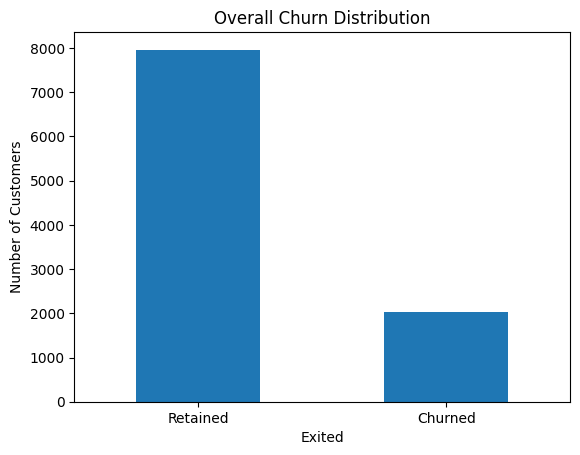

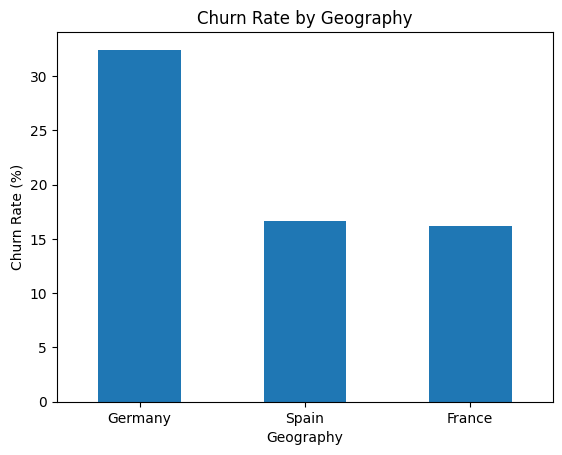

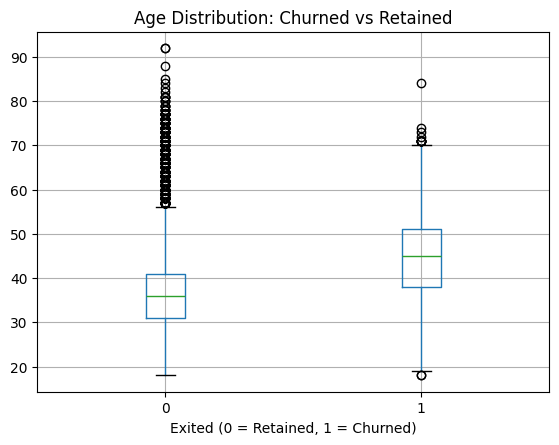

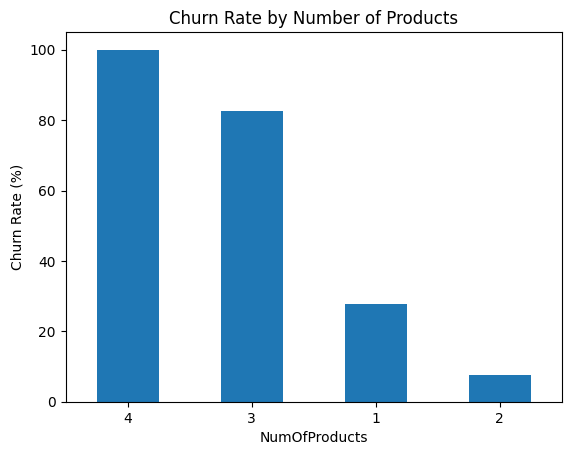

In [3]:
"""
Customer Churn Prediction — Week 1: Dataset + SQL + Cleaning
Dataset: Bank Customer Churn (Kaggle), 10,000 rows, target column 'Exited'.
"""

import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = "Churn_Modelling.csv"  # rename to match your downloaded file


# ---------------------------------------------------------------------------
# Load & inspect
# ---------------------------------------------------------------------------
def load_data(path: str = DATA_PATH) -> pd.DataFrame:
    try:
        df = pd.read_csv(path)
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"Dataset not found at '{path}'. Download it from Kaggle and "
            "upload it to your working directory first."
        ) from e
    return df


# ---------------------------------------------------------------------------
# Clean
# ---------------------------------------------------------------------------
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Drop duplicates, drop ID columns that don't help prediction, check nulls."""
    before = len(df)
    df = df.drop_duplicates()

    # Columns that identify a customer but carry no predictive signal
    id_cols = [c for c in ["RowNumber", "CustomerId", "Surname"] if c in df.columns]
    df = df.drop(columns=id_cols)

    dropped = before - len(df)
    if dropped:
        print(f"Dropped {dropped} duplicate row(s).")

    null_counts = df.isnull().sum()
    if null_counts.any():
        print("Null values found:\n", null_counts[null_counts > 0])
    else:
        print("No null values found.")

    return df


# ---------------------------------------------------------------------------
# SQL analysis
# ---------------------------------------------------------------------------
def build_sql_connection(df: pd.DataFrame) -> sqlite3.Connection:
    conn = sqlite3.connect(":memory:")
    df.to_sql("customers", conn, index=False, if_exists="replace")
    return conn


def run_query(conn: sqlite3.Connection, query: str) -> pd.DataFrame:
    try:
        return pd.read_sql_query(query, conn)
    except (sqlite3.OperationalError, pd.errors.DatabaseError) as e:
        raise RuntimeError(f"SQL query failed: {e}\nQuery:\n{query}") from e


OVERALL_CHURN_RATE_QUERY = """
    SELECT
        ROUND(100.0 * SUM(Exited) / COUNT(*), 2) AS churn_rate_pct,
        COUNT(*) AS total_customers,
        SUM(Exited) AS churned_customers
    FROM customers
"""

CHURN_BY_GEOGRAPHY_QUERY = """
    SELECT
        Geography,
        COUNT(*) AS total_customers,
        SUM(Exited) AS churned,
        ROUND(100.0 * SUM(Exited) / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY Geography
    ORDER BY churn_rate_pct DESC
"""

CHURN_BY_AGE_GROUP_QUERY = """
    SELECT
        CASE
            WHEN Age < 30 THEN 'Under 30'
            WHEN Age < 40 THEN '30-39'
            WHEN Age < 50 THEN '40-49'
            WHEN Age < 60 THEN '50-59'
            ELSE '60+'
        END AS age_group,
        COUNT(*) AS total_customers,
        SUM(Exited) AS churned,
        ROUND(100.0 * SUM(Exited) / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY age_group
    ORDER BY churn_rate_pct DESC
"""

CHURN_BY_ACTIVITY_QUERY = """
    SELECT
        IsActiveMember,
        COUNT(*) AS total_customers,
        SUM(Exited) AS churned,
        ROUND(100.0 * SUM(Exited) / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY IsActiveMember
"""

AVG_BALANCE_BY_CHURN_QUERY = """
    SELECT
        Exited,
        ROUND(AVG(Balance), 2) AS avg_balance,
        ROUND(AVG(EstimatedSalary), 2) AS avg_salary,
        ROUND(AVG(Tenure), 2) AS avg_tenure
    FROM customers
    GROUP BY Exited
"""


# ---------------------------------------------------------------------------
# Visualizations
# ---------------------------------------------------------------------------
def plot_churn_distribution(df: pd.DataFrame) -> None:
    df["Exited"].value_counts().rename({0: "Retained", 1: "Churned"}).plot(
        kind="bar", title="Overall Churn Distribution"
    )
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=0)
    plt.show()


def plot_churn_by_geography(df: pd.DataFrame) -> None:
    (
        df.groupby("Geography")["Exited"].mean().sort_values(ascending=False) * 100
    ).plot(kind="bar", title="Churn Rate by Geography")
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=0)
    plt.show()


def plot_churn_by_age(df: pd.DataFrame) -> None:
    df.boxplot(column="Age", by="Exited")
    plt.title("Age Distribution: Churned vs Retained")
    plt.suptitle("")
    plt.xlabel("Exited (0 = Retained, 1 = Churned)")
    plt.show()


def plot_churn_by_products(df: pd.DataFrame) -> None:
    (
        df.groupby("NumOfProducts")["Exited"].mean().sort_values(ascending=False) * 100
    ).plot(kind="bar", title="Churn Rate by Number of Products")
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=0)
    plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    df = load_data()
    df = clean_data(df)
    df.to_csv("churn_clean.csv", index=False)

    conn = build_sql_connection(df)
    print("\n--- Overall Churn Rate ---")
    print(run_query(conn, OVERALL_CHURN_RATE_QUERY))
    print("\n--- Churn by Geography ---")
    print(run_query(conn, CHURN_BY_GEOGRAPHY_QUERY))
    print("\n--- Churn by Age Group ---")
    print(run_query(conn, CHURN_BY_AGE_GROUP_QUERY))
    print("\n--- Churn by Activity Status ---")
    print(run_query(conn, CHURN_BY_ACTIVITY_QUERY))
    print("\n--- Avg Balance/Salary/Tenure by Churn Status ---")
    print(run_query(conn, AVG_BALANCE_BY_CHURN_QUERY))

    plot_churn_distribution(df)
    plot_churn_by_geography(df)
    plot_churn_by_age(df)
    plot_churn_by_products(df)


if __name__ == "__main__":
    main()

Key Insights:

1. Geography: Germany has by far the highest churn rate (~32%) compared to
Spain (16.67%) and France (16.15%) - customers in Germany are roughly twice
as likely to leave as customers in either other country.

2. Age Group: Churn rises sharply with age - customers 50-59 churn at 56.04%,
more than double the 40-49 group (30.79%) and over 7x the Under-30 group
(7.56%). This is the strongest pattern in the data.

3. Activity Status: Inactive members churn nearly 2x as often as active ones
(26.85% vs. 14.27%), confirming engagement is a meaningful retention signal.

4. Balance: Churned customers had a higher average balance ($91,108.54) than
retained customers ($72,745.30) - the bank isn't just losing low-value
customers, it's losing wealthier ones.

5. Tenure: Tenure barely differs between churned (4.93 yrs) and retained
(5.03 yrs) customers - unlike age or activity, how long someone's been a
customer isn't a strong churn predictor on its own.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Train: 8000 rows | Test: 2000 rows
Churn rate  train: 20.38% | test: 20.35%

Benchmark: always predicting 'Retained' is 79.7% accurate.
Any real model has to be judged on more than accuracy.

Classification report (Baseline Logistic Regression):
              precision    recall  f1-score   support

    Retained       0.84      0.97      0.90      1593
     Churned       0.68      0.27      0.39       407

    accuracy                           0.83      2000
   macro avg       0.76      0.62      0.64      2000
weighted avg       0.81      0.83      0.79      2000

ROC-AUC: 0.795



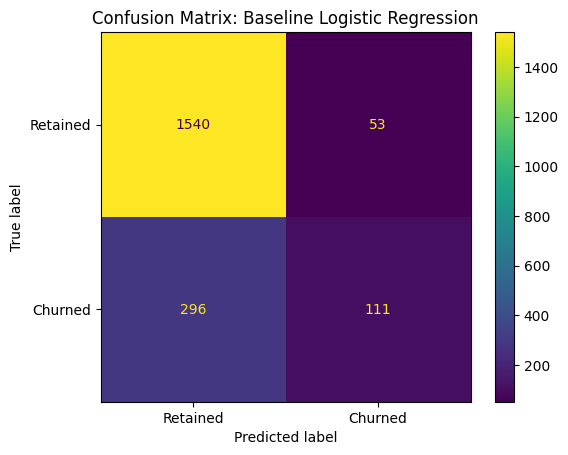

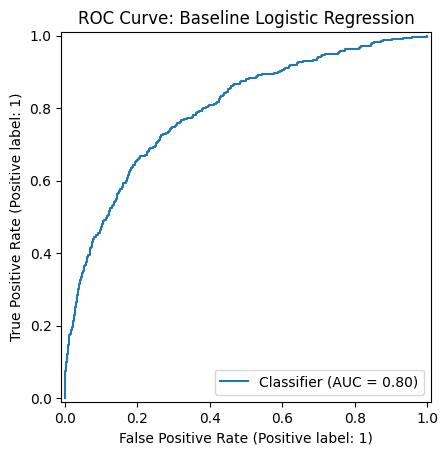

Top 10 features by coefficient size:
cat__AgeGroup_50-59       1.032
bin__IsActiveMember      -0.970
cat__AgeGroup_30-39      -0.592
cat__AgeGroup_Under 30   -0.568
cat__AgeGroup_60+        -0.499
num__Age                  0.463
cat__Gender_Male         -0.440
cat__Geography_Germany    0.383
cat__Geography_France    -0.383
cat__Geography_Spain     -0.352
dtype: float64


In [6]:
"""
Customer Churn Prediction — Week 2: Feature Engineering + Baseline Model
Uses churn_clean.csv (saved by the Week 1 script). Target column: 'Exited'.
"""

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
CLEAN_DATA_PATH = "churn_clean.csv"
TARGET = "Exited"
RANDOM_STATE = 42
TEST_SIZE = 0.2

NUMERIC_FEATURES = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "EstimatedSalary", "BalanceSalaryRatio",
]
CATEGORICAL_FEATURES = ["Geography", "Gender", "AgeGroup", "TenureGroup"]
BINARY_FEATURES = ["HasCrCard", "IsActiveMember", "HasZeroBalance"]


# ---------------------------------------------------------------------------
# Load & feature engineering
# ---------------------------------------------------------------------------
def load_clean_data(path: str = CLEAN_DATA_PATH) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"'{path}' not found. Run the Week 1 script first (it saves "
            "churn_clean.csv), or upload the file to Colab."
        ) from e


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create new columns from existing ones. None of these use the target,
    so they can't leak the answer into the model."""
    df = df.copy()

    # How large the balance is relative to income (salary is never 0 here)
    df["BalanceSalaryRatio"] = df["Balance"] / df["EstimatedSalary"]

    # Many customers hold a zero balance; that is its own behavior pattern
    df["HasZeroBalance"] = (df["Balance"] == 0).astype(int)

    # Churn vs. age is not a straight line (peaks at 50-59), so bin it
    df["AgeGroup"] = pd.cut(
        df["Age"],
        bins=[0, 29, 39, 49, 59, 120],
        labels=["Under 30", "30-39", "40-49", "50-59", "60+"],
    ).astype(str)

    df["TenureGroup"] = pd.cut(
        df["Tenure"],
        bins=[-1, 2, 5, 8, 10],
        labels=["0-2", "3-5", "6-8", "9-10"],
    ).astype(str)

    return df


# ---------------------------------------------------------------------------
# Split (stratified, BEFORE any scaling/encoding is fit)
# ---------------------------------------------------------------------------
def split_data(df: pd.DataFrame):
    X = df.drop(columns=[TARGET])
    y = df[TARGET]
    return train_test_split(
        X, y,
        test_size=TEST_SIZE,
        stratify=y,  # keeps the ~20% churn rate the same in train and test
        random_state=RANDOM_STATE,
    )


# ---------------------------------------------------------------------------
# Model pipeline
# ---------------------------------------------------------------------------
def build_pipeline() -> Pipeline:
    """Preprocessing + logistic regression in one object. Because scaling and
    encoding live inside the pipeline, they are fit on training data only."""
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
            ("bin", "passthrough", BINARY_FEATURES),
        ]
    )
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ]
    )


# ---------------------------------------------------------------------------
# Evaluation
# ---------------------------------------------------------------------------
def evaluate(pipeline: Pipeline, X_train, X_test, y_train, y_test) -> None:
    # 1) The "do nothing" benchmark: always predict the majority class
    dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
    dummy_acc = dummy.score(X_test, y_test)
    print(f"Benchmark: always predicting 'Retained' is {dummy_acc:.1%} accurate.")
    print("Any real model has to be judged on more than accuracy.\n")

    # 2) The baseline model
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print("Classification report (Baseline Logistic Regression):")
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}\n")

    # 3) Plots
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Retained", "Churned"]
    )
    plt.title("Confusion Matrix: Baseline Logistic Regression")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("ROC Curve: Baseline Logistic Regression")
    plt.show()


def show_coefficients(pipeline: Pipeline, top_n: int = 10) -> pd.Series:
    """Largest positive/negative coefficients = features pushing churn up/down.
    (Features are scaled, so magnitudes are roughly comparable.)"""
    names = pipeline.named_steps["preprocess"].get_feature_names_out()
    coefs = pd.Series(pipeline.named_steps["model"].coef_[0], index=names)
    ranked = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
    print(f"Top {top_n} features by coefficient size:")
    print(ranked.head(top_n).round(3))
    return ranked


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    df = load_clean_data()
    df = add_features(df)

    X_train, X_test, y_train, y_test = split_data(df)
    print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
    print(f"Churn rate  train: {y_train.mean():.2%} | test: {y_test.mean():.2%}\n")

    pipeline = build_pipeline()
    pipeline.fit(X_train, y_train)

    evaluate(pipeline, X_train, X_test, y_train, y_test)
    show_coefficients(pipeline)


if __name__ == "__main__":
    main()

## Baseline Model: Logistic Regression

**Setup:** 80/20 stratified train/test split (8,000 train / 2,000 test rows), so the ~20% churn rate is the same in both sets. Scaling and one-hot encoding are fit inside a Scikit-learn pipeline, so they only learn from training data (no leakage). Added features: BalanceSalaryRatio, HasZeroBalance, AgeGroup, TenureGroup.

**Results on the test set:**
- Accuracy: 83% (a model that always predicts "Retained" scores 79.7%)
- Churned class: precision 0.68, recall 0.27, F1 0.39
- ROC-AUC: 0.795

**Confusion matrix:** 1,540 retained customers correctly predicted, 53 false alarms, 296 churners missed, 111 churners caught.

**Interpretation:** Accuracy looks decent but is misleading because only ~20% of customers churn. The model catches just 27% of the customers who actually leave (296 of 407 missed), although it is right 68% of the time when it does flag someone. The ROC-AUC of 0.795 shows the model has real predictive signal, so the low recall comes mostly from the default 0.5 decision threshold on imbalanced data, not from a lack of signal. Next step: handle class imbalance, compare tree-based models, and tune the threshold.
